In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
S = 7
R = 10000
PRECIO = 9.50
PRESUPUESTO = 1000.0
PRECIO_CAJA = 975.0
SOBRES_CAJA = 104

np.random.seed(2026)

In [2]:
# ============================================================
# ETAPA 3
# Incorporación del presupuesto y costo
# ============================================================

print("================================================")
print("RESULTADOS ETAPA 3")
print("================================================\n")

# ============================================================
# SIMULACIÓN CON PRESUPUESTO (SOBRES SUELTOS)
# ============================================================

completados = []
sobres_comprados = []
estampas_finales = []

for _ in range(R):

    album = np.zeros(N, dtype=bool)
    gasto = 0.0
    sobres = 0

    while gasto + PRECIO <= PRESUPUESTO and not np.all(album):

        sobre = np.random.choice(N, size=S, replace=False)
        album[sobre] = True
        gasto += PRECIO
        sobres += 1

    completados.append(int(np.all(album)))
    sobres_comprados.append(sobres)
    estampas_finales.append(np.sum(album))

completados = np.array(completados)
sobres_comprados = np.array(sobres_comprados)
estampas_finales = np.array(estampas_finales)

# ============================================================
# ESTADÍSTICAS SOBRES SUELTOS
# ============================================================

prob_exito = np.mean(completados)
media_sobres = np.mean(sobres_comprados)
media_estampas_fallo = np.mean(estampas_finales[completados == 0])

print(f"Probabilidad de completar el álbum: {prob_exito:.4f}")
print(f"Sobres esperados comprados: {media_sobres:.4f}")
print(f"Estampas distintas promedio (casos fallidos): {media_estampas_fallo:.4f}\n")


RESULTADOS ETAPA 3

Probabilidad de completar el álbum: 0.9488
Sobres esperados comprados: 71.6088
Estampas distintas promedio (casos fallidos): 98.9609



In [3]:
# ============================================================
# PREGUNTA 1 - MÁXIMO DE SOBRES Y MÍNIMO TEÓRICO
# ============================================================

max_sobres = int(PRESUPUESTO // PRECIO)
min_teorico = int(np.ceil(N / S))

print(f"1. Máximo de sobres con Q{PRESUPUESTO:.2f}: {max_sobres}")
print(f"   Mínimo teórico sin repetidos: {min_teorico}")
print(f"   Con {max_sobres} sobres se obtienen hasta {max_sobres * S} estampas")
print(f"   ¿Es suficiente en teoría?: {'Sí' if max_sobres * S >= N else 'No'}\n")

1. Máximo de sobres con Q1000.00: 105
   Mínimo teórico sin repetidos: 15
   Con 105 sobres se obtienen hasta 735 estampas
   ¿Es suficiente en teoría?: Sí



In [4]:
# ============================================================
# PREGUNTA 2 - SIMULACIÓN CON CAJA
# ============================================================

completados_caja = []

for _ in range(R):

    album = np.zeros(N, dtype=bool)

    for _ in range(SOBRES_CAJA):
        sobre = np.random.choice(N, size=S, replace=False)
        album[sobre] = True

    completados_caja.append(int(np.all(album)))

completados_caja = np.array(completados_caja)
prob_caja = np.mean(completados_caja)

print(f"2. Probabilidad completar con caja ({SOBRES_CAJA} sobres): {prob_caja:.4f}")
print(f"   Probabilidad completar con sobres sueltos: {prob_exito:.4f}")
print(f"   Diferencia: {prob_caja - prob_exito:+.4f}")
print(f"   ¿Conviene la caja?: {'Sí' if prob_caja > prob_exito else 'No'}\n")

2. Probabilidad completar con caja (104 sobres): 0.9500
   Probabilidad completar con sobres sueltos: 0.9488
   Diferencia: +0.0012
   ¿Conviene la caja?: Sí



In [5]:
# ============================================================
# PREGUNTA 3 - ESTRATEGIA MIXTA
# ============================================================

restante = PRESUPUESTO - PRECIO_CAJA
sobres_extra = int(restante // PRECIO)
total_mixta = SOBRES_CAJA + sobres_extra

completados_mixta = []

for _ in range(R):

    album = np.zeros(N, dtype=bool)

    for _ in range(total_mixta):
        sobre = np.random.choice(N, size=S, replace=False)
        album[sobre] = True

    completados_mixta.append(int(np.all(album)))

completados_mixta = np.array(completados_mixta)
prob_mixta = np.mean(completados_mixta)

print(f"3. Presupuesto restante tras caja: Q{restante:.2f}")
print(f"   Sobres adicionales posibles: {sobres_extra}")
print(f"   Total sobres estrategia mixta: {total_mixta}")
print(f"   Probabilidad completar (mixta): {prob_mixta:.4f}\n")

3. Presupuesto restante tras caja: Q25.00
   Sobres adicionales posibles: 2
   Total sobres estrategia mixta: 106
   Probabilidad completar (mixta): 0.9565



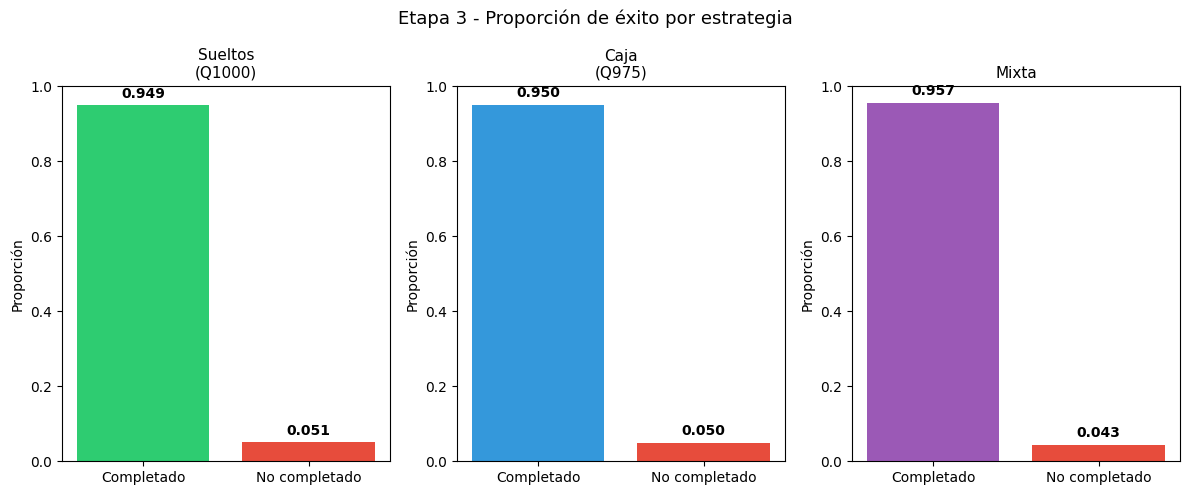

In [13]:
# ============================================================
# VISUALIZACIÓN ETAPA 3
# ============================================================

etiquetas = [f'Sueltos\n(Q{PRESUPUESTO:.0f})', f'Caja\n(Q{PRECIO_CAJA:.0f})', 'Mixta']
probs = [prob_exito, prob_caja, prob_mixta]
colores = ['#2ecc71', '#3498db', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, etiqueta, prob, color in zip(axes, etiquetas, probs, colores):

    ax.bar(['Completado', 'No completado'], [prob, 1 - prob],
           color=[color, '#e74c3c'])
    ax.set_title(etiqueta, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Proporción')

    for j, v in enumerate([prob, 1 - prob]):
        ax.text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Etapa 3 - Proporción de éxito por estrategia', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# ETAPA 4
# Efecto del intercambio de repetidas
# ============================================================

print("================================================")
print("RESULTADOS ETAPA 4")
print("================================================\n")

np.random.seed(2026)

K_valores = [1, 2, 5, 10]

# ============================================================
# PARTE A - SIMULACIÓN HASTA COMPLETAR EL ÁLBUM
# ============================================================

print("PARTE A - Sobres hasta completar\n")

# Referencia sin intercambio
sobres_sin = []

for _ in range(R):

    album = np.zeros(N, dtype=bool)
    sobres = 0
    distintas = 0

    while distintas < N:
        sobre = np.random.choice(N, size=S, replace=False)
        for e in sobre:
            if not album[e]:
                album[e] = True
                distintas += 1
        sobres += 1

    sobres_sin.append(sobres)

sobres_sin = np.array(sobres_sin)
media_sin = np.mean(sobres_sin)
std_sin = np.std(sobres_sin)

print(f"Sin intercambio --> media = {media_sin:.4f}  std = {std_sin:.4f}")

resultados_k = {}

for K in K_valores:

    sobres_k = []

    for _ in range(R):

        coleccion = set()
        repetidas = 0
        sobres = 0

        while len(coleccion) < N:

            sobre = np.random.choice(N, size=S, replace=False)

            for e in sobre:
                if e in coleccion:
                    repetidas += 1
                else:
                    coleccion.add(e)

            sobres += 1

            if repetidas >= K:
                faltantes = list(set(range(N)) - coleccion)
                if len(faltantes) > 0:
                    coleccion.add(faltantes[0])
                    repetidas -= K

        sobres_k.append(sobres)

    sobres_k = np.array(sobres_k)
    media_k = np.mean(sobres_k)
    std_k = np.std(sobres_k)
    reduccion = (media_sin - media_k) / media_sin * 100

    resultados_k[K] = sobres_k

    print(f"K = {K:2d} --> media = {media_k:.4f}  std = {std_k:.4f}  reducción = {reduccion:.2f}%")

RESULTADOS ETAPA 4

PARTE A - Sobres hasta completar

Sin intercambio --> media = 72.2456  std = 17.4715
K =  1 --> media = 28.8396  std = 1.9132  reducción = 60.08%
K =  2 --> media = 29.0631  std = 1.9017  reducción = 59.77%
K =  5 --> media = 29.9215  std = 1.8529  reducción = 58.58%
K = 10 --> media = 35.1815  std = 2.4569  reducción = 51.30%


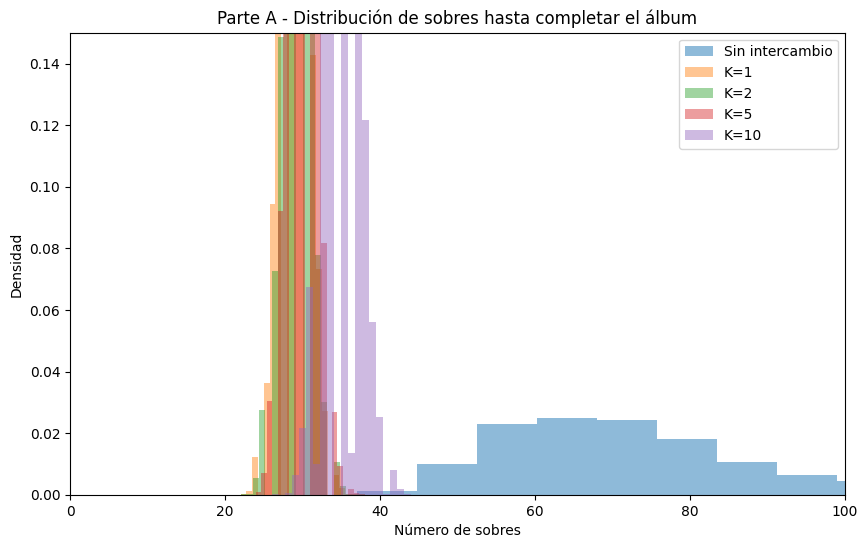

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(sobres_sin, bins=20, alpha=0.5, label='Sin intercambio', density=True)

for K in K_valores:
    plt.hist(resultados_k[K], bins=20, alpha=0.45, label=f'K={K}', density=True)

plt.xlim(0, 100)
plt.ylim(0, 0.15)
plt.xlabel("Número de sobres")
plt.ylabel("Densidad")
plt.title("Parte A - Distribución de sobres hasta completar el álbum")
plt.legend()
plt.show()


In [22]:
# ============================================================
# PARTE B - PROBABILIDAD DE ÉXITO VS M
# ============================================================

print("\nPARTE B - Probabilidad de éxito vs M\n")

M_valores = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

# Sin intercambio
probs_sin = []

for M in M_valores:

    exitos = 0

    for _ in range(R):

        album = np.zeros(N, dtype=bool)

        for _ in range(M):
            sobre = np.random.choice(N, size=S, replace=False)
            album[sobre] = True

        if np.all(album):
            exitos += 1

    probs_sin.append(exitos / R)

print("Sin intercambio:")
for M, p in zip(M_valores, probs_sin):
    print(f"  M = {M:3d} --> P = {p:.4f}")

# Con intercambio por K
probs_k = {}

for K in K_valores:

    probs_k[K] = []
    print(f"\nK = {K}:")

    for M in M_valores:

        exitos = 0

        for _ in range(R):

            coleccion = set()
            repetidas = 0

            for _ in range(M):

                sobre = np.random.choice(N, size=S, replace=False)

                for e in sobre:
                    if e in coleccion:
                        repetidas += 1
                    else:
                        coleccion.add(e)

                if repetidas >= K:
                    faltantes = list(set(range(N)) - coleccion)
                    if len(faltantes) > 0:
                        coleccion.add(faltantes[0])
                        repetidas -= K

                if len(coleccion) == N:
                    break

            if len(coleccion) == N:
                exitos += 1

        probs_k[K].append(exitos / R)
        print(f"  M = {M:3d} --> P = {exitos/R:.4f}")


PARTE B - Probabilidad de éxito vs M

Sin intercambio:
  M =  20 --> P = 0.0000
  M =  25 --> P = 0.0000
  M =  30 --> P = 0.0000
  M =  35 --> P = 0.0000
  M =  40 --> P = 0.0014
  M =  45 --> P = 0.0167
  M =  50 --> P = 0.0614
  M =  55 --> P = 0.1427
  M =  60 --> P = 0.2610
  M =  65 --> P = 0.4013
  M =  70 --> P = 0.5291

K = 1:
  M =  20 --> P = 0.0000
  M =  25 --> P = 0.0352
  M =  30 --> P = 0.8003
  M =  35 --> P = 0.9995
  M =  40 --> P = 1.0000
  M =  45 --> P = 1.0000
  M =  50 --> P = 1.0000
  M =  55 --> P = 1.0000
  M =  60 --> P = 1.0000
  M =  65 --> P = 1.0000
  M =  70 --> P = 1.0000

K = 2:
  M =  20 --> P = 0.0000
  M =  25 --> P = 0.0250
  M =  30 --> P = 0.7821
  M =  35 --> P = 0.9997
  M =  40 --> P = 1.0000
  M =  45 --> P = 1.0000
  M =  50 --> P = 1.0000
  M =  55 --> P = 1.0000
  M =  60 --> P = 1.0000
  M =  65 --> P = 1.0000
  M =  70 --> P = 1.0000

K = 5:
  M =  20 --> P = 0.0000
  M =  25 --> P = 0.0061
  M =  30 --> P = 0.6308
  M =  35 --> P = 0.

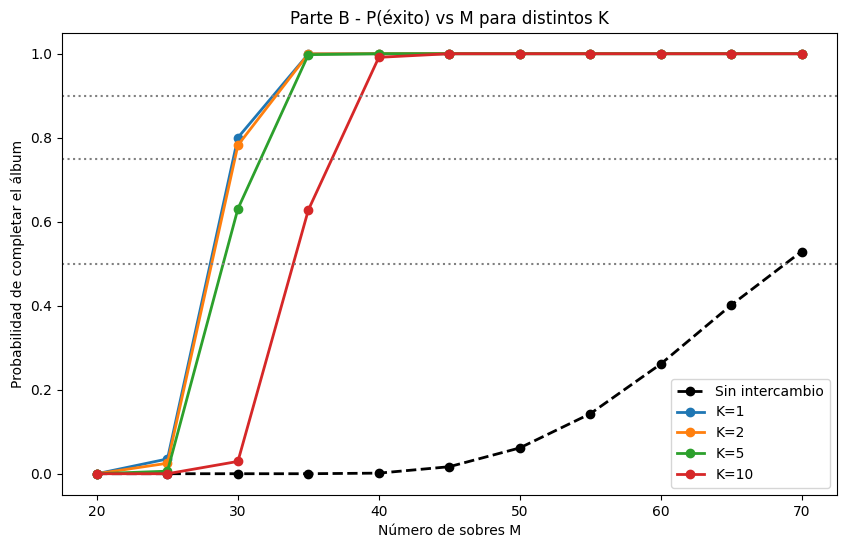

In [23]:
# ============================================================
# GRÁFICA PARTE B
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(M_valores, probs_sin, 'k--o', label='Sin intercambio', linewidth=2)

for K in K_valores:
    plt.plot(M_valores, probs_k[K], '-o', label=f'K={K}', linewidth=2)

plt.axhline(0.5, linestyle=':', color='gray')
plt.axhline(0.75, linestyle=':', color='gray')
plt.axhline(0.9, linestyle=':', color='gray')

plt.xlabel("Número de sobres M")
plt.ylabel("Probabilidad de completar el álbum")
plt.title("Parte B - P(éxito) vs M para distintos K")
plt.legend()
plt.show()

In [24]:
# ============================================================
# UMBRALES 50%, 75%, 90%
# ============================================================

print("\n================================================")
print("UMBRALES DE PROBABILIDAD")
print("================================================\n")

umbrales = [0.50, 0.75, 0.90]

todas = {'Sin intercambio': probs_sin}
for K in K_valores:
    todas[f'K={K}'] = probs_k[K]

for nombre, probs in todas.items():

    fila = f"{nombre:>16}  "

    for u in umbrales:
        m = next((M_valores[j] for j, p in enumerate(probs) if p >= u), '>70')
        fila += f"  {int(u*100)}%: M={m}"

    print(fila)


UMBRALES DE PROBABILIDAD

 Sin intercambio    50%: M=70  75%: M=>70  90%: M=>70
             K=1    50%: M=30  75%: M=30  90%: M=35
             K=2    50%: M=30  75%: M=30  90%: M=35
             K=5    50%: M=30  75%: M=35  90%: M=35
            K=10    50%: M=35  75%: M=40  90%: M=40


In [25]:
# ============================================================
# PREGUNTAS DE ANÁLISIS ETAPA 4
# ============================================================

# Pregunta 1
print("================================================")
print("PREGUNTAS DE ANÁLISIS ETAPA 4")
print("================================================\n")

print("1. Efecto de disminuir K:")
for K in K_valores:
    media_k = np.mean(resultados_k[K])
    reduccion = (media_sin - media_k) / media_sin * 100
    print(f"   K={K:2d} --> media = {media_k:.2f} sobres  reducción = {reduccion:.2f}%")
print("   La relación NO es lineal: pasar de K=10 a K=5 reduce más")
print("   que pasar de K=2 a K=1.\n")

# Pregunta 2
media_k2 = np.mean(resultados_k[2])
ahorro = media_sin - media_k2
ahorro_q = ahorro * PRECIO

print(f"2. Ahorro K=2 vs sin intercambio:")
print(f"   Sin intercambio: {media_sin:.2f} sobres")
print(f"   K=2: {media_k2:.2f} sobres")
print(f"   Ahorro: {ahorro:.2f} sobres --> Q{ahorro_q:.2f}\n")

# Pregunta 3
idx_45 = M_valores.index(45)
print(f"3. P(éxito) a M=45:")
print(f"   Sin intercambio: {probs_sin[idx_45]:.4f}")
for K in K_valores:
    print(f"   K={K:2d}: {probs_k[K][idx_45]:.4f}")
print()

# Pregunta 4
print("4. Valor de K con poco beneficio adicional:")
for K in K_valores:
    media_k = np.mean(resultados_k[K])
    reduccion = (media_sin - media_k) / media_sin * 100
    print(f"   K={K:2d} --> reducción acumulada = {reduccion:.2f}%")
print("   A partir de K=2 la mejora adicional es pequeña.")
print("   De K=2 a K=1 la reducción extra es mínima.\n")

# Pregunta 5
print("5. Costo efectivo por estampa nueva via canje:")
for K in K_valores:
    costo = (K * PRECIO) / S
    print(f"   K={K:2d} --> Q{costo:.4f} por estampa")
print("   K=1 es la tasa más rentable por estampa obtenida.")

PREGUNTAS DE ANÁLISIS ETAPA 4

1. Efecto de disminuir K:
   K= 1 --> media = 28.84 sobres  reducción = 60.08%
   K= 2 --> media = 29.06 sobres  reducción = 59.77%
   K= 5 --> media = 29.92 sobres  reducción = 58.58%
   K=10 --> media = 35.18 sobres  reducción = 51.30%
   La relación NO es lineal: pasar de K=10 a K=5 reduce más
   que pasar de K=2 a K=1.

2. Ahorro K=2 vs sin intercambio:
   Sin intercambio: 72.25 sobres
   K=2: 29.06 sobres
   Ahorro: 43.18 sobres --> Q410.23

3. P(éxito) a M=45:
   Sin intercambio: 0.0167
   K= 1: 1.0000
   K= 2: 1.0000
   K= 5: 1.0000
   K=10: 1.0000

4. Valor de K con poco beneficio adicional:
   K= 1 --> reducción acumulada = 60.08%
   K= 2 --> reducción acumulada = 59.77%
   K= 5 --> reducción acumulada = 58.58%
   K=10 --> reducción acumulada = 51.30%
   A partir de K=2 la mejora adicional es pequeña.
   De K=2 a K=1 la reducción extra es mínima.

5. Costo efectivo por estampa nueva via canje:
   K= 1 --> Q1.3571 por estampa
   K= 2 --> Q2.7143 p